# 5.Predict_test
テストデータを予測する

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

import lightgbm as lgb

from rdkit import Chem
from rdkit.Chem import Draw

import optuna
import joblib
import os

from scipy.spatial.distance import cdist
from sklearn.svm import OneClassSVM

import optuna

## データ読み込み

### 学習データ読み込み

In [2]:
# 入力：読み込みたい記述子のタイプを選択
descriptor_type = "mordred_3d"  # 'rdkit' or 'mordred_2d' or 'mordred_3d' or 'fp'

dataset = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset[["Emission max (nm)", "Quantum yield"]]

if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0
    )
elif descriptor_type == "mordred_3d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0
    )
elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 目的変数と記述子を結合
dataset_train = target.join(des, how="inner")
print(target.shape, des.shape, dataset_train.shape)

(13132, 2) (13132, 1382) (13132, 1384)


### テストデータ読み込み

In [3]:
# 入力：読み込みたい記述子のタイプを選択
descriptor_type = "mordred_3d"  # 'rdkit' or 'mordred_2d' or 'mordred_3d' or 'fp'

# dataset = pd.read_csv("../data/dataset_test.csv", index_col=0)

if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0
    )
elif descriptor_type == "mordred_3d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0
    )
elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 目的変数と記述子を結合
X_test = des
print(des.shape, X_test.shape)

(7104, 1382) (7104, 1382)


## 予測

### D最適基準

In [4]:
# D最適基準で X_test の候補を間引く（ランダムサーチ）
number_of_selecting_samples = 3000   # 選択したい候補数
number_of_random_searches = 500      # D最適探索の反復回数
random_state = 1234

# 候補集合内で標準化（D最適計算用）
autoscaled_X_test = (X_test - X_test.mean()) / X_test.std()
autoscaled_X_test = autoscaled_X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

all_indexes = np.arange(X_test.shape[0])
rng = np.random.default_rng(random_state)

best_d_optimal_value = -np.inf
selected_sample_indexes = None
epsilon = 1e-8  # 特異行列対策

for _ in range(number_of_random_searches):
    # ランダムサーチで候補を選択
    new_selected_indexes = rng.choice(
        all_indexes, size=number_of_selecting_samples, replace=False
    )
    new_selected_samples = autoscaled_X_test.iloc[new_selected_indexes, :]

    # D最適基準の計算（X'X が特異でも計算できるように微小な正則化を加える）
    # mordred3dの記述子は多重共線性が強いため、εIをX'Xに加える
    xt_x = np.dot(new_selected_samples.T, new_selected_samples)
    xt_x_reg = xt_x + epsilon * np.eye(xt_x.shape[0])
    sign, logdet = np.linalg.slogdet(xt_x_reg)
    d_optimal_value = logdet if sign > 0 else -np.inf

    # 初回は必ず採用し、その後は最大値で更新
    if (selected_sample_indexes is None) or (d_optimal_value > best_d_optimal_value):
        best_d_optimal_value = d_optimal_value
        selected_sample_indexes = new_selected_indexes.copy()

selected_sample_indexes = sorted(selected_sample_indexes.tolist())
selected_test_tags = X_test.index[selected_sample_indexes]

print(f"selected: {len(selected_test_tags)} / {X_test.shape[0]}")
print(f"best log(det(X'X + epsI)): {best_d_optimal_value:.3f}")

selected: 3000 / 7104
best log(det(X'X + epsI)): -3249.992


In [5]:
# 選択済み / 非選択のテストデータを作成
X_test_d_opt = X_test.loc[selected_test_tags].copy()
X_test_remaining = X_test.drop(index=selected_test_tags)

print("X_test_d_opt:", X_test_d_opt.shape)
print("X_test_remaining:", X_test_remaining.shape)

# 必要なら保存
# os.makedirs("outputs/result/doe", exist_ok=True)
# X_test_d_opt.to_csv("outputs/result/doe/X_test_d_opt.csv")
# X_test_remaining.to_csv("outputs/result/doe/X_test_remaining.csv")

X_test_d_opt.head()

X_test_d_opt: (3000, 1382)
X_test_remaining: (4104, 1382)


,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Tag,,,,,,,,,,,,,,,,,,,,,
1,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,4.652435,0.160429,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
3,2,0,41.407230,2.603784,5.207568,41.407230,1.254765,4.440806,5.001998,0.151576,...,10.833149,70.214037,969.484623,27.699561,2564,72,186.0,234.0,14.750000,7.000000
6,2,0,41.407230,2.603784,5.207568,41.407230,1.254765,4.440806,5.001998,0.151576,...,10.833149,70.214037,969.484623,27.699561,2564,72,186.0,234.0,14.750000,7.000000
8,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,4.652435,0.160429,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444
10,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,4.652435,0.160429,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444


### テストデータ予測

In [6]:
# 保存したLGB(emi + qy)を呼び出して予測する

def load_artifact_with_fallback(path_candidates):
    for p in path_candidates:
        if os.path.exists(p):
            return joblib.load(p), p
    raise FileNotFoundError(f"artifact not found: {path_candidates}")

artifact_emi, emi_path = load_artifact_with_fallback([
    "models/lgb/artifact_lgb_mordred_3d_emi.joblib",
    "models/lgb/artifact_lgb_mordred_3d.joblib",
])
artifact_qy, qy_path = load_artifact_with_fallback([
    "models/lgb/artifact_lgb_mordred_3d_qy.joblib",
])

model_emi = artifact_emi["model"] if isinstance(artifact_emi, dict) else artifact_emi
model_qy = artifact_qy["model"] if isinstance(artifact_qy, dict) else artifact_qy

feature_columns_emi = (
    artifact_emi["feature_columns"]
    if isinstance(artifact_emi, dict)
    else dataset_train.drop(columns=["Emission max (nm)", "Quantum yield"]).columns.tolist()
)
feature_columns_qy = (
    artifact_qy["feature_columns"]
    if isinstance(artifact_qy, dict)
    else dataset_train.drop(columns=["Emission max (nm)", "Quantum yield"]).columns.tolist()
)

# D最適で間引いた集合があればそれを優先
X_test_for_pred = X_test_d_opt if "X_test_d_opt" in globals() else X_test

# 学習時の列順に合わせる
X_test_emi = X_test_for_pred.reindex(columns=feature_columns_emi)
X_test_qy = X_test_for_pred.reindex(columns=feature_columns_qy)

# 予測
y_pred_emi = model_emi.predict(X_test_emi)
y_pred_qy = model_qy.predict(X_test_qy)

# 予測結果を統合（qyは0-1スケール想定）
pred_df = pd.DataFrame(
    {
        "emi_pred": y_pred_emi,
        "qy_pred": y_pred_qy,
    },
    index=X_test_for_pred.index,
)

print("emi model:", emi_path)
print("qy  model:", qy_path)
print("predict rows:", pred_df.shape[0])
pred_df.head()


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


emi model: models/lgb/artifact_lgb_mordred_3d_emi.joblib
qy  model: models/lgb/artifact_lgb_mordred_3d_qy.joblib
predict rows: 3000


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,emi_pred,qy_pred
Tag,,
1,543.062591,0.519244
3,573.501892,0.103990
6,573.501892,0.098864
8,549.947591,0.100072
10,543.062591,0.519244


## AD判定

In [10]:
# ADモデル用に標準化（emissionモデルのx_scalerを再利用）
X_train_ad = dataset_train.drop(columns=["Emission max (nm)", "Quantum yield"])
X_train_ad = X_train_ad.reindex(columns=feature_columns_emi)
X_test_ad = X_test_for_pred.reindex(columns=feature_columns_emi)

# model_emi が TransformedTargetRegressor + Pipeline の想定
ad_scaler = None
if hasattr(model_emi, "regressor_") and hasattr(model_emi.regressor_, "named_steps"):
    ad_scaler = model_emi.regressor_.named_steps.get("x_scaler", None)

# 念のためのフォールバック（構造が異なる場合）
if ad_scaler is None:
    ad_scaler = StandardScaler()
    ad_scaler.fit(X_train_ad.values)

autoscaled_X_train = ad_scaler.transform(X_train_ad.values)
autoscaled_X_test = ad_scaler.transform(X_test_ad.values)

print("autoscaled_X_train:", autoscaled_X_train.shape)
print("autoscaled_X_test :", autoscaled_X_test.shape)

autoscaled_X_train: (13132, 1382)
autoscaled_X_test : (3000, 1382)


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
def gamma_optimization_with_variance(x, gammas):
    """
    DataFrame型もしくはarray型のxにおいて、カーネル関数におけるグラム行列の分散を最大化することにより、yを最適化する関数

    Parameters
    -----------------------------------
    x : pandas.DataFrame or numpy.array
    gammas : list

    Returns
    -------
    optimized gamma : scaler

    """

    print('カーネル関数においてグラム行列の分散を最大化することによりγの最適化')

    variance_of_gamma_matrix = []

    for index, ocsvm_gamma in enumerate(gammas):
        # print(index + 1, '/', len(gammas))
        gram_matrix = np.exp(-ocsvm_gamma * cdist(x, x, metric='sqeuclidean'))
        variance_of_gamma_matrix.append(gram_matrix.var(ddof=1))

    return gammas[variance_of_gamma_matrix.index(max(variance_of_gamma_matrix))]

In [12]:
# OCSVMによるAD
# OCSVMにおけるnu, nu=0.317(σ), nu=0.045(2σ), nu=0.003(3σ)など選択でき、学習時の境界の形・きつさを決めるハイパラ
# 学習データのうち、最大でnuだけを境界の外にしても良いという上限を与える（サポートベクタ比の下限）
# nuの値が大きくなるとADは狭まるが誤差は小さくなり、nuが小さくなるとADは広がるが、誤差は大きくなる
# nu=0.317ならば、約68%のデータが含まれる範囲（±1σ相当）を定義するイメージ、ただし直感的なイメージであって、厳密な対応ではない。
ocsvm_nu = 0.003

# γの候補
ocsvm_gammas = 2 ** np.arange(-20, 11, dtype=float)

# グラム行列の分散を最大化することによるγの候補、最も情報量の多いγを選ぶことができる
optimal_ocsvm_gamma = gamma_optimization_with_variance(autoscaled_X_train, ocsvm_gammas)

print('最適化されたgamma(OCSVM) :', optimal_ocsvm_gamma)

カーネル関数においてグラム行列の分散を最大化することによりγの最適化
最適化されたgamma(OCSVM) : 0.00048828125


In [13]:
# ADモデル構築
ocsvm_model = OneClassSVM(kernel="rbf", gamma=optimal_ocsvm_gamma, nu=ocsvm_nu)
ocsvm_model.fit(autoscaled_X_train)

# density
data_density_train = ocsvm_model.decision_function(autoscaled_X_train).ravel()
data_density_test  = ocsvm_model.decision_function(autoscaled_X_test).ravel()

# しきい値（trainの下位25%を外）
threshold_percentile = 25
threshold = np.percentile(data_density_train, threshold_percentile)

in_ad_ocsvm = data_density_test >= threshold

print(f"OCSVM-AD threshold (p{threshold_percentile}): {threshold:.6f}")
print(f"OCSVM-AD in: {in_ad_ocsvm.sum()} / {len(in_ad_ocsvm)}")

OCSVM-AD threshold (p25): 0.356245
OCSVM-AD in: 2242 / 3000


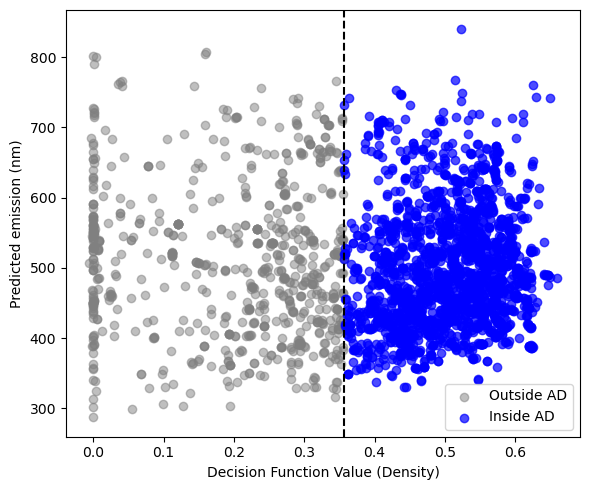

In [14]:
# density ≥ threshold のインデックス
in_ad_index = data_density_test >= threshold
out_ad_index = data_density_test < threshold

plt.figure(figsize=(6, 5))

plt.scatter(
    data_density_test[out_ad_index],
    pred_df["emi_pred"].iloc[out_ad_index],
    color="gray", alpha=0.5, label="Outside AD"
)

plt.scatter(
    data_density_test[in_ad_index],
    pred_df["emi_pred"].iloc[in_ad_index],
    color="blue", alpha=0.7, label="Inside AD"
)

plt.axvline(x=threshold, color="black", linestyle="--")
plt.xlabel("Decision Function Value (Density)")
plt.ylabel("Predicted emission (nm)")
plt.legend()
plt.tight_layout()
plt.show()

## Filtering
AD内のテストデータで発光波長が600nm以上、且つ量子収率が50%以上と予測されたテストデータのみ抽出。

In [15]:
# AD内かつ、発光波長 >= 600 nm、量子収率 >= 50% (0.5) を抽出
qy_threshold = 0.5  # Quantum yield は 0-1 スケール想定

result_df = pred_df.copy()
result_df["in_ad"] = in_ad_ocsvm

selected_candidates = result_df[
    (result_df["in_ad"])
    & (result_df["emi_pred"] >= 600)
    & (result_df["qy_pred"] >= qy_threshold)
].sort_values(["emi_pred", "qy_pred"], ascending=False)

print("selected candidates:", selected_candidates.shape[0])
selected_candidates.head(20)

selected candidates: 46


,emi_pred,qy_pred,in_ad
Tag,,,
7575,731.789245,0.592990,True
16322,709.847472,0.528861,True
16318,709.847472,0.526759,True
7356,708.777229,0.683020,True
7555,691.728755,0.575444,True
7551,690.251552,0.570394,True
16280,690.251552,0.566490,True
7399,672.768673,0.732747,True
7105,669.462306,0.682415,True


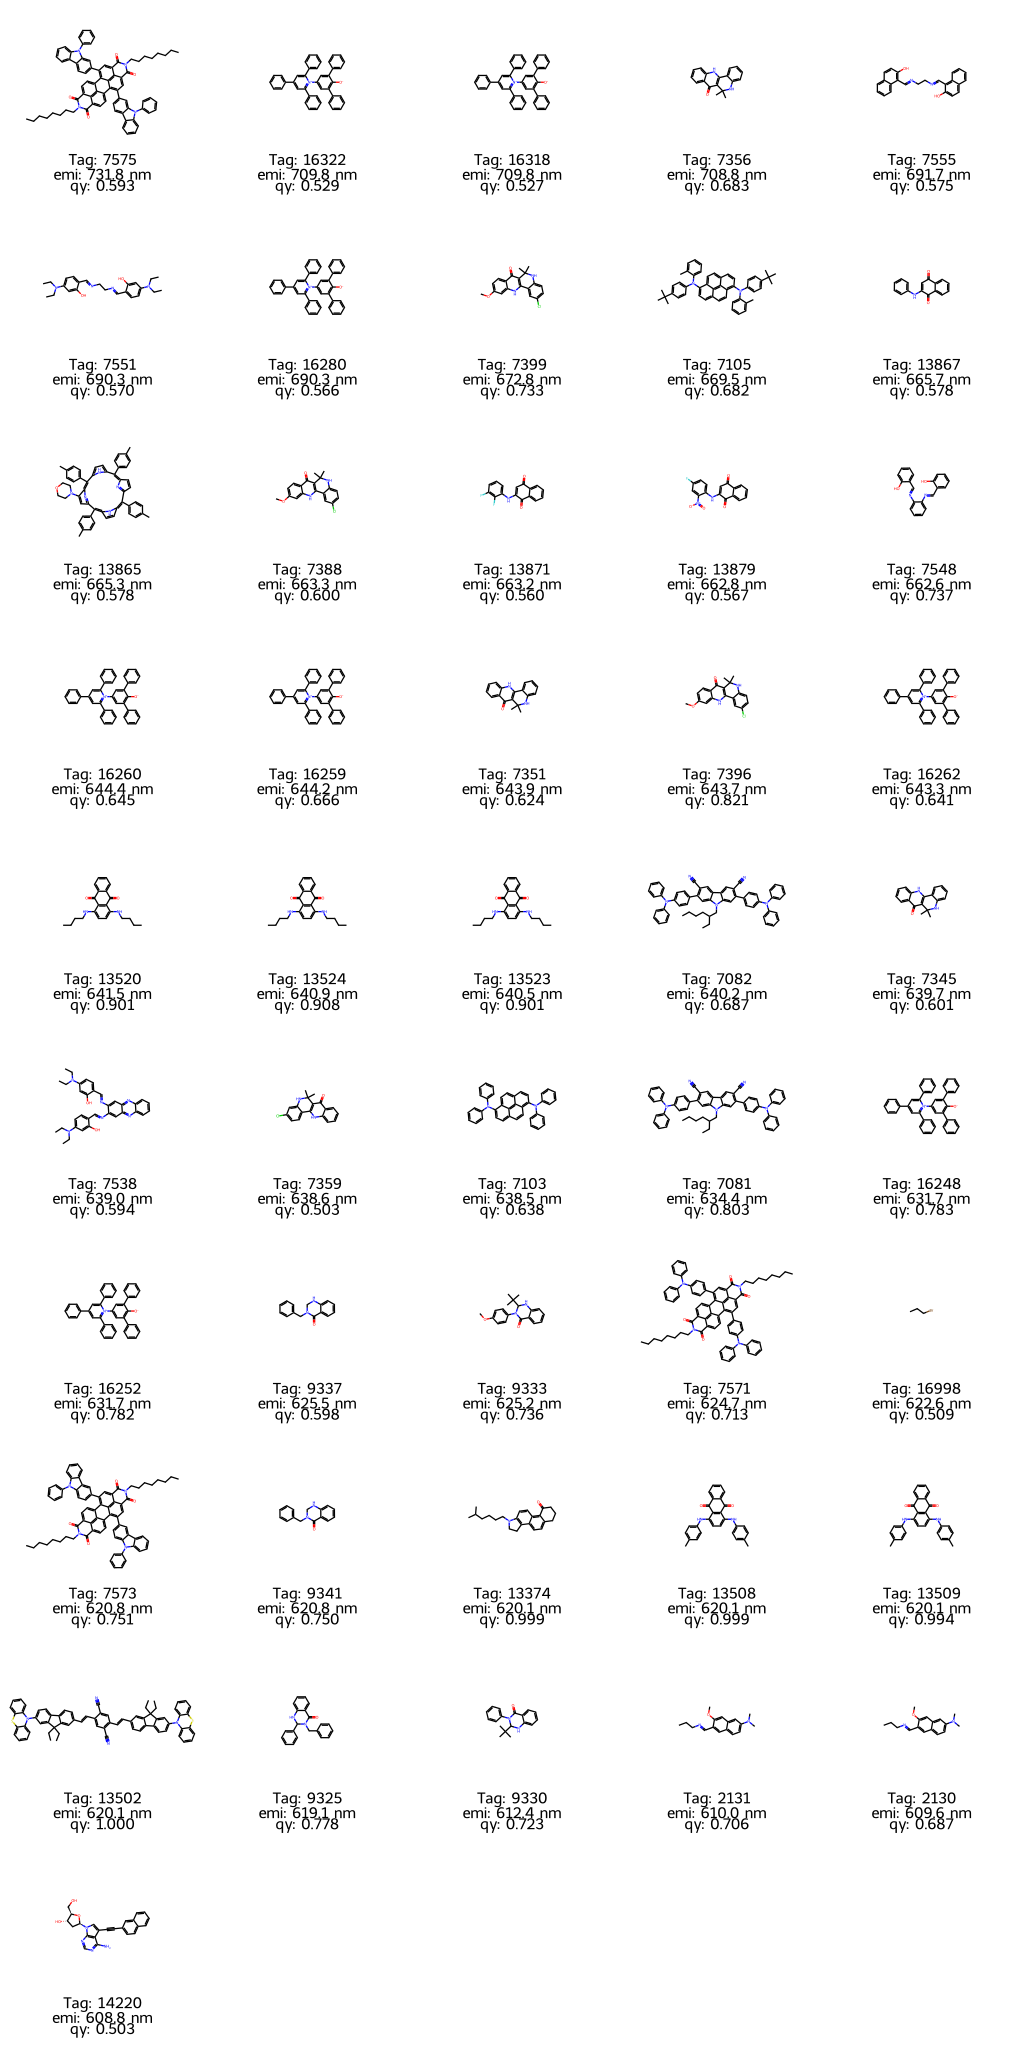

In [24]:
# selected_candidates の全件を RDKit でグリッド表示（legendにemi/qy付き）
from IPython.display import display

tags = selected_candidates.index.tolist()

# train/test の Chromophore を結合
dataset_test = pd.read_csv("../data/dataset_test.csv", index_col=0)
chromophore = pd.concat(
    [
        dataset["Chromophore"],
        dataset_test["Chromophore"],
    ]
)
chromophore = chromophore[~chromophore.index.duplicated(keep="first")]

smiles = chromophore.loc[tags]
mols = [Chem.MolFromSmiles(str(s)) for s in smiles]

legends = [
    f"Tag: {tag}\nemi: {selected_candidates.loc[tag, 'emi_pred']:.1f} nm\nqy: {selected_candidates.loc[tag, 'qy_pred']:.3f}"
    for tag in tags
]

# RDKitの描画オプションを先に設定（バージョン差異対応）
# Qiita記事のやり方で legend サイズを調整
options = Draw.MolDrawOptions()
options.legendFontSize = 32   # まずは24前後が見やすい
options.legendFraction = 0.22 # 複数行legend用に領域を広めに確保

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(320, 320),
        legends=legends,
        drawOptions=options,
        useSVG=True,
    )
)